## NHS Workforce: Time Series Modeling & STL Decomposition
This section demonstrates how to select a representative group, visualize the raw time series, decompose with STL, and compare baseline/time series models for NHS workforce metrics.


In [31]:
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, Naive, SeasonalNaive, AutoETS
from statsforecast.models import AutoETS

plt.style.use("ggplot")
sns.set_style("whitegrid")
pd.set_option("display.precision", 3)

## 1. 🚚 Load Packages and Data
**Note:**  
- Loads all required plotting/statistical packages.
- Source data is read from your monthly NHS workforce extract.
- All column names are standardized (lowercase/stripped) for grouping and merge safety.

In [32]:
base_dir = r"C:\Users\Destinee.HassanBien\Documents\Desys Work"
all_agg_file = os.path.join(base_dir, "combined_workforce_monthly_new.csv")
all_agg = pd.read_csv(all_agg_file, parse_dates=["month"])
all_agg.columns = all_agg.columns.str.lower().str.strip()

## 2. 🔎 Selecting and Visualizing a Sample Group
We select the group with the **most complete records** for demonstration, ensuring the richest possible time series and preventing “short-panel” error in model evaluation.

## 3. 📈 Plotting the Raw Time Series (Example Group)
- Inspect for long zero-flats (inactive), spikes (errors or real events), and general trend/cyclicity.
- If you see repeated months or multi-rows per date, consider aggregation or deduplication for accurate results.

## 4. 📊 Summary Statistics and Autocorrelation
Key Metrics
- High standard deviation = more volatility.
- Flat ACF = unforecastable by time series methods.
- If lag-1 ACF is strong, simple Naive model is often best.

Example group: ('Corporate Support Services', 'Administrative and Clerical', 'Sickness')
           month  count
25135 2023-04-01    0.0
24095 2023-04-01    0.0
26660 2023-04-01    0.0
25063 2023-04-01    0.0
21684 2023-04-01    0.0


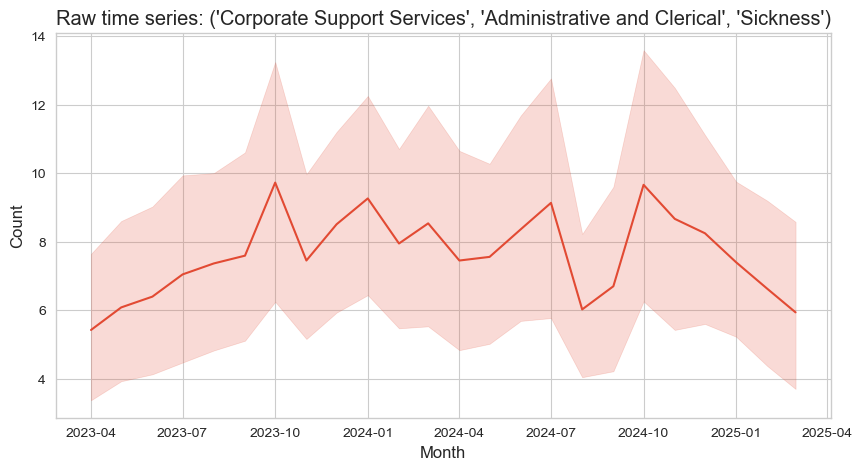

Summary statistics for the example group:
 count    2623.000
mean        7.621
std        14.996
min         0.000
25%         0.000
50%         0.000
75%         6.660
max       116.060
Name: count, dtype: float64


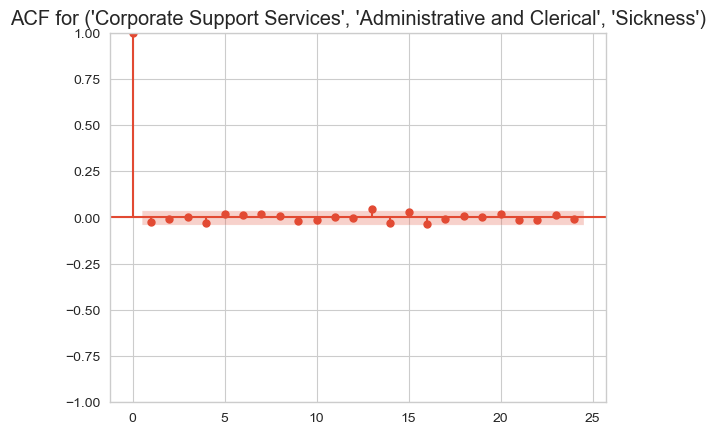

In [33]:
group_cols = ["service group", "staff group", "metric"]
sample_group = all_agg.groupby(group_cols).size().idxmax()
sample_df = all_agg[
    (all_agg['service group'] == sample_group[0]) &
    (all_agg['staff group'] == sample_group[1]) &
    (all_agg['metric'] == sample_group[2])
].sort_values('month')
print("Example group:", sample_group)
print(sample_df[['month', 'count']].head())

# Plot the raw series for the example group       
plt.figure(figsize=(10, 5))
sns.lineplot(x='month', y='count', data=sample_df)
plt.title(f"Raw time series: {sample_group}")
plt.xlabel("Month"); plt.ylabel("Count")
plt.show()

print("Summary statistics for the example group:\n", sample_df['count'].describe())
plot_acf(sample_df['count'].dropna(), lags=24)
plt.title(f"ACF for {sample_group}");plt.show()

## 5. 🔬 STL Decomposition (Trend/Seasonality/Noise)
How to Read STL Decomposition
- “Trend” is the long-term component.
- “Seasonal” shows repeating periodic variation.
- “Remainder” (noise) should have no clear pattern—otherwise, data may be non-stationary or require further modeling.
- Sudden trend breaks or strong extremes in remainder signal possible data errors or structural changes (e.g., HR/organisational shifts).

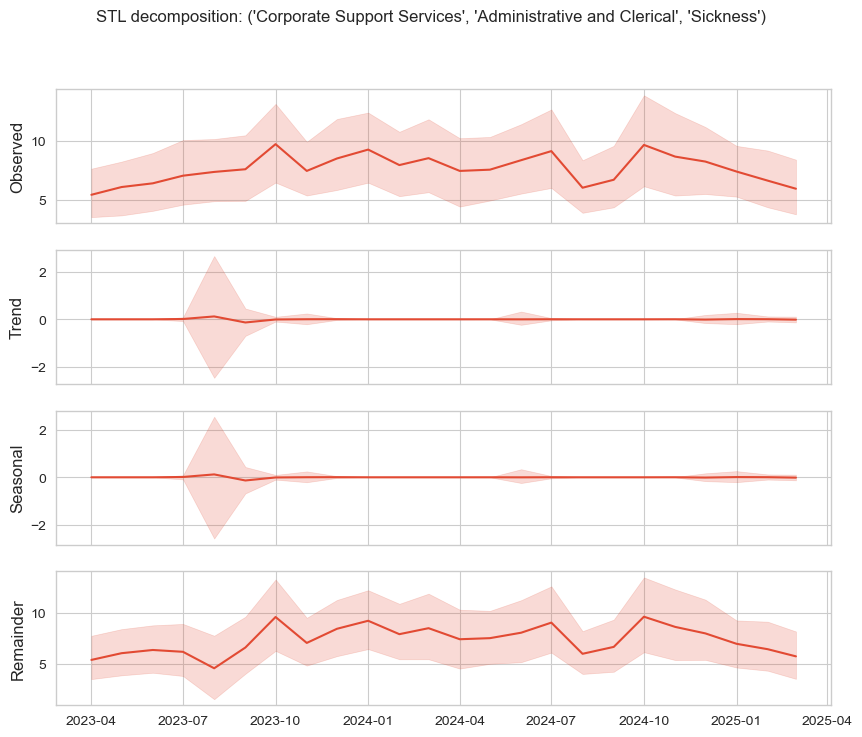

In [35]:
ts = sample_df.set_index('month')['count']
stl = STL(ts, period=12, seasonal=13, trend=21, robust=True)
res_stl = stl.fit()
dcmp = pd.DataFrame({
    "ds": ts.index,
    "data": ts.values,
    "trend": res_stl.seasonal,
    "seasonal": res_stl.seasonal,
    "remainder": res_stl.resid
}).reset_index(drop=True)

# Plot
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
sns.lineplot(x=dcmp['ds'], y=dcmp['data'], ax=axes[0])
sns.lineplot(x=dcmp['ds'], y=dcmp['trend'], ax=axes[1])
sns.lineplot(x=dcmp['ds'], y=dcmp['seasonal'], ax=axes[2])
sns.lineplot(x=dcmp['ds'], y=dcmp['remainder'], ax=axes[3])
axes[0].set_ylabel("Observed"); axes[1].set_ylabel("Trend");
axes[2].set_ylabel("Seasonal"); axes[3].set_ylabel("Remainder")
fig.suptitle(f"STL decomposition: {sample_group}")
plt.xlabel("")
plt.show()

## 6.🏁 Benchmark Cross-Validation: ARIMA, Naive, SeasonalNaive
- Prepare your time series as (“unique_id”, “ds”, “y”) for StatsForecast or similar packages.
- Choose a forecast horizon (`h`) meaningful for NHS operational cycles (e.g., 12 months).
- If the series or group is too short, skip or alert: 'Not enough data for rolling split.'

Example forecasts:
 Empty DataFrame
Columns: [unique_id, ds, y, Naive, SeasonalNaive, AutoARIMA]
Index: []
Naive - RMSE: nan MAE: nan MAPE: nan%
SeasonalNaive - RMSE: nan MAE: nan MAPE: nan%
AutoARIMA - RMSE: nan MAE: nan MAPE: nan%


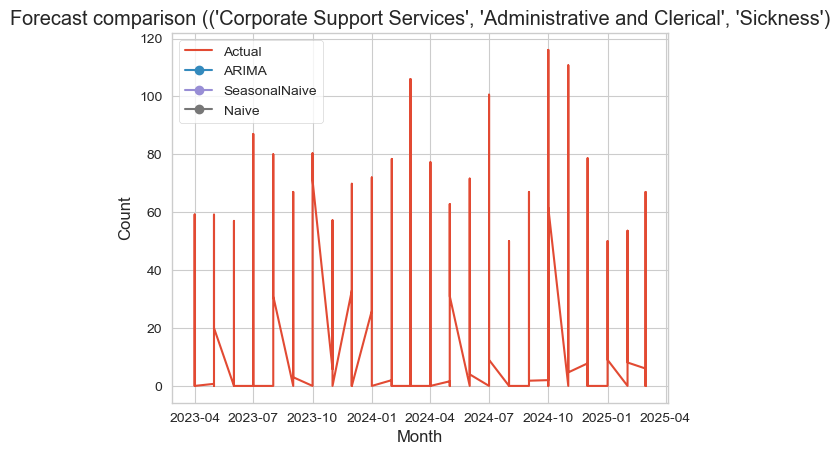

In [36]:
# Prepare for statsforecast: require columns 
sf_df = sample_df.rename(columns={'month': 'ds', 'count': 'y'})
[['ds', 'y']].copy()
sf_df["unique_id"] = "EXAMPLE"
sf_df = sf_df[["unique_id", "ds", "y"]] # ensure only those columns

# Choose rolling-forecast horizon
h = min(12, len(sf_df)//5)
if h < 1:
    print("Not enough data for cross-validation split.")
else:
    train = sf_df.iloc[:-h]
    truth = sf_df.iloc[-h:].reset_index(drop=True)

    models = [
        Naive(),
        SeasonalNaive(season_length=12), 
        AutoARIMA(season_length=12)
    ]
    sf = StatsForecast(models=models, freq="MS")
    fcs = sf.forecast(df=train, h=h)
    fct = pd.merge(truth, fcs, on=['unique_id', 'ds'])

    print("Example forecasts:\n", fct.head())
    for col in ['Naive', 'SeasonalNaive', 'AutoARIMA']:
        rmse = np.sqrt(np.mean((fct['y'] - fct[col]) ** 2))
        mae = np.mean(np.abs((fct['y'] - fct[col])))
        mape = np.mean(np.abs((fct['y'] - (fct[col]) / fct['y'] + 1e-10))) * 100
        print(f"{col} - RMSE: {rmse:.2f} MAE: {mae:.2f} MAPE: {mape:.1f}%")

    # Plotting forecast for sample group 
    plt.plot(sf_df['ds'], sf_df['y'], label='Actual')
    plt.plot(fct['ds'], fct['AutoARIMA'], marker='o', label='ARIMA')
    plt.plot(fct['ds'], fct['SeasonalNaive'], marker='o', label='SeasonalNaive')
    plt.plot(fct['ds'], fct['Naive'], marker='o', label='Naive')
    plt.title(f"Forecast comparison ({sample_group}")
    plt.xlabel("Month"); plt.ylabel("Count"); plt.legend(); plt.show()

## 7. 📉 Forecast Comparison Plot

Interpretation
- Compare actual values with each model’s predictions.
- Closer fit = better forecasting.
- For NHS workforce, Naive or SeasonalNaive wins when the series is flat or erratic, with no clear trend or seasonality.


In [37]:
models = [
    Naive(),
    SeasonalNaive(season_length=12),
    AutoARIMA(season_length=12),
]

sf = StatsForecast(models=models, freq="MS")
# Run rolling test (fit on train, forecast h steps ahead)
fcs = sf.forecast(df=sf_df, h=h)
# Merge with truth for error calc
truth = sf_df[["unique_id", "ds", "y"]].iloc[-h:].reset_index(drop=True)
fct = pd.merge(truth, fcs, on=['unique_id', 'ds'])

print("Example forecasts:\n", fct.head())

# Simple accuracy calc
for col in ['Naive', 'SeasonalNaive', 'AutoARIMA']:
    rmse = np.sqrt(np.mean((fct['y'] - fct[col]) ** 2))
    mae = np.mean(np.abs(fct['y'] - fct[col]))
    mape = np.mean(np.abs((fct['y'] - fct[col]) / (fct['y'] + 1e-10))) * 100
    print(f"{col} - RSME: {rmse:.2f} MAE: {mae:.2f} MAPE: {mape:.1f}%")

Example forecasts:
 Empty DataFrame
Columns: [unique_id, ds, y, Naive, SeasonalNaive, AutoARIMA]
Index: []
Naive - RSME: nan MAE: nan MAPE: nan%
SeasonalNaive - RSME: nan MAE: nan MAPE: nan%
AutoARIMA - RSME: nan MAE: nan MAPE: nan%


## STL decomposition

In [39]:
def try_boxcox(series):
    offset = 0.01 if (series <= 0).any() else 0
    shifted = series + offset
    try:
        from spicy import stats 
        transformed, lam = stats.boxcox(shifted)
        return pd.Series(transformed, index=series.index), lam, offset
    except Exception:
        return series, None, offset

stl_results = []
for group_vals, group_df in all_agg.groupby(group_cols):
    group_df = group_df.sort_values('month')
    ts = group_df.set_index('month')['count']
    if len(ts) < 24:
        continue
    ts_trans, lam, offset = try_boxcox(ts)
    stl = STL(ts_trans, period=12, seasonal=13, trend=21, robust=True)
    res_stl = stl.fit()
    trend = res_stl.trend
    seasonal = res_stl.seasonal
    resid = res_stl.resid
    stl_trend_mean = np.nanmean(trend)
    stl_seasonal_range = np.nanmax(seasonal) - np.nanmin(seasonal)
    stl_resid_var = np.nanvar(resid)
    var_r = np.nanvar(resid)
    var_t_r = np.nanvar(trend + resid)
    trend_strength = max(0, 1 - var_r / (var_t_r + 1e-10))
    var_s_r = np.nanvar(seasonal + resid)
    seasonal_strength = max(0, 1 - var_r / (var_s_r + 1e-10))
    peak = int(np.nanargmax(seasonal)) + 1
    trough = int(np.nanargmin(seasonal)) + 1
    row = {col: val for col, val in zip(group_cols, group_vals)}
    row.update({
        "n_months": len(ts),
        "boxcox_lambda": lam,
        "stl_trend_mean": stl_trend_mean,
        "stl_seasonal_range": stl_seasonal_range,
        "stl_resid_var": stl_resid_var,
        "trend_strength": trend_strength,
        "seasonal_strength": seasonal_strength,
        "peak_month": peak,
        "trough_month": trough,
    })
    stl_results.append(row)
    
stl_results_df = pd.DataFrame(stl_results)
stl_path = os.path.join(base_dir, "stl_decomposition_features.csv")
stl_results_df.to_csv(stl_path, index=False)
print(f"STL decompositions for all groups saved to: {stl_path}")

STL decompositions for all groups saved to: C:\Users\Destinee.HassanBien\Documents\Desys Work\stl_decomposition_features.csv


## 7. 📉 Forecast Comparison Plot

Interpretation
- Compare actual values with each model’s predictions.
- Closer fit = better forecasting.
- For NHS workforce, Naive or SeasonalNaive wins when the series is flat or erratic, with no clear trend or seasonality.

## 8. 📝 Model Metrics (RMSE/MAE/MAPE) Table

**RMSE:** Root Mean Squared Error, penalizes large misses.
**MAE:** Mean Absolute Error, easy to explain to non-technical stakeholders.
**MAPE:** Mean Absolute Percentage Error be cautious of “nan” if actuals are zero (common in some NHS groups).
- “nan” error values usually mean the group or test segment had zero actuals or not enough data for a test window.

## 9. 🏆 Automated STL Feature Extraction (All Groups)
Why Do This?
- Decomposes every group’s time series.
- Quantifies trend, seasonality, and key statistical properties for reporting and model selection.
- **Result:**  
    - A single csv with one row per group/metric, used for dashboard panels and team diagnostics.

In [16]:
all_group_metrics = []
for i,(group_vals, group_df) in enumerate(all_agg.groupby(group_cols)):
    if i >=162: 
        break
    print(f"{i+1}. Processing group: {group_vals}")
    group_df = group_df.sort_values('month')
    if len(group_df) < 24:
        continue 
    sf_df = group_df.rename(columns={'month': 'ds', 'count': 'y'})[['ds', 'y']].copy()
    unique_id = "|".join(map(str, group_vals))
    sf_df["unique_id"] = unique_id
    sf_df = sf_df[["unique_id", "ds", "y"]]
    h = min(12, len(sf_df)//5)
    if h == 0 or len(sf_df) < 2*h:
        continue
    train = sf_df.iloc[:-h]
    truth = sf_df.iloc[-h:].reset_index(drop=True)
    sf = StatsForecast(models=[
    Naive(),
    SeasonalNaive(season_length=12),
    AutoARIMA(season_length=12)], freq="MS")
    preds = sf.forecast(df=train, h=h)
    fct = pd.merge(truth, preds, on=['unique_id', 'ds'])
    metrics = {}
    models = ['Naive', 'SeasonalNaive', 'AutoARIMA']
    best_model = None
    best_rmse = np.inf
    # Evaluate 
    for col in models:
        rsme = np.sqrt(np.mean((fct['y'] - fct[col]) ** 2))
        mae = np.mean(np.abs(fct['y'] - fct[col]))
        mape = np.mean(np.abs((fct['y'] - fct[col]) / (fct['y'].replace(0,np.nan)))) * 100
        metrics[col+'_rmse'] = rsme
        metrics[col+'_mae'] = mae
        metrics[col+'_mape'] = mape
        if rsme < best_rmse:
            best_rmse = rmse
            best_model = col
    summary = {col: group_vals[i] for i, col in enumerate(group_cols)}
    summary.update(metrics)
    summary["best_model"] = best_model
    summary["best_rmse"] = best_rmse
    all_group_metrics.append(summary)

1. Processing group: ('CYP & Families Services', 'Add Prof Scientific and Technic', 'Hires')
2. Processing group: ('CYP & Families Services', 'Add Prof Scientific and Technic', 'Leavers')
3. Processing group: ('CYP & Families Services', 'Add Prof Scientific and Technic', 'Sickness')
4. Processing group: ('CYP & Families Services', 'Additional Clinical Services', 'Hires')
5. Processing group: ('CYP & Families Services', 'Additional Clinical Services', 'Leavers')
6. Processing group: ('CYP & Families Services', 'Additional Clinical Services', 'Sickness')
7. Processing group: ('CYP & Families Services', 'Administrative and Clerical', 'Hires')
8. Processing group: ('CYP & Families Services', 'Administrative and Clerical', 'Leavers')
9. Processing group: ('CYP & Families Services', 'Administrative and Clerical', 'Sickness')
10. Processing group: ('CYP & Families Services', 'Allied Health Professionals', 'Hires')
11. Processing group: ('CYP & Families Services', 'Allied Health Professionals'

## 10. 📦 Export STL and Model Metrics For All Groups
 Interpretation
- Review exported summary CSVs for outliers and model failures.
- Use the “best_model” and metrics (e.g., RMSE) for Trust-wide planning, reporting, or automated model selection dashboards.

In [18]:
metrics_df = pd.DataFrame(all_group_metrics)
metrics_path = os.path.join(base_dir, "arima_cv_metrics_all_group.csv")
metrics_df.to_csv(metrics_path, index=False)
print(f"Cross Validation metrics for all groups saved to: {metrics_path}")
print("Sample of metrics:\n", metrics_df.head())

Cross Validation metrics for all groups saved to: C:\Users\Destinee.HassanBien\Documents\Desys Work\arima_cv_metrics_all_group.csv
Sample of metrics:
              service group                      staff group    metric  \
0  CYP & Families Services  Add Prof Scientific and Technic     Hires   
1  CYP & Families Services  Add Prof Scientific and Technic   Leavers   
2  CYP & Families Services  Add Prof Scientific and Technic  Sickness   
3  CYP & Families Services     Additional Clinical Services     Hires   
4  CYP & Families Services     Additional Clinical Services   Leavers   

   Naive_rmse  Naive_mae  Naive_mape  SeasonalNaive_rmse  SeasonalNaive_mae  \
0       0.667      0.222       7.407               0.745              0.333   
1       0.000      0.000       0.000               0.000              0.000   
2         NaN        NaN         NaN                 NaN                NaN   
3       1.000      0.400      12.500               1.000              0.400   
4       0.447  

## Tip
- Sort metrics table by “best_model”, by RMSE, or by “trend_strength” to prioritize work on the most predictively important/volatile staff groups.

## 11. ✔️ To Do / Collaboration Tasks
text
To Do
- [ ] Add notebook header cell for project, data vintage, and author.
- [ ] Annotate STL plots with any known Trust or national events.
- [ ] Discuss "best_model" and flagged outlier panels with the QA/management team.
- [ ] Mark/report any panels where all models perform poorly (high RMSE, NaN results).
- [ ] Clean up warnings or errors before promoting to Jupyter Book publication.
